# Detecção de Defeitos em PCBs utilizando RT-DETR

>&nbsp;&nbsp;&nbsp;&nbsp;Alexandre Augusto Tescaro Oliveira

## 1. Introdução e Motivação

> **Resumo do Estudo:** Este trabalho apresenta o desenvolvimento de um sistema de Visão Computacional para detecção automática de defeitos em Placas de Circuito Impresso (PCBs), utilizando a arquitetura **RT-DETR** (Real-Time DEtection TRansformer). Para viabilizar a execução local e manter comparação consistente entre modelos, o conjunto de dados foi organizado preservando a distribuição das classes de defeito. Os resultados obtidos são comparados com os modelos YOLOv11, Faster R-CNN e RetinaNet.

### 1.1 Contextualização
No cenário da Indústria 4.0, a garantia de qualidade na fabricação de componentes eletrônicos é crítica para reduzir perdas, retrabalho e falhas em campo. As Placas de Circuito Impresso (PCBs) são a base de praticamente todos os dispositivos eletrônicos modernos. Com a miniaturização dos componentes, a inspeção visual tornou-se mais complexa e exige soluções automáticas robustas.

### 1.2 O Problema
Tradicionalmente, a inspeção de PCBs é realizada de forma manual por operadores humanos ou por algoritmos de visão clássica baseados em regras rígidas. Esses métodos apresentam limitações no ambiente industrial:
>* **Fadiga Humana:** A inspeção visual repetitiva aumenta a chance de erro e inconsistências.
>* **Baixa Escalabilidade:** A inspeção manual é lenta e cria gargalos na linha de produção.
>* **Sensibilidade de Regras:** Métodos clássicos falham com variações de iluminação, rotação e ruído.

### 1.3 A Solução Proposta
Para reduzir esses problemas e automatizar o processo de inspeção, este notebook adota Deep Learning com **RT-DETR** (Real-Time DEtection TRansformer), uma arquitetura baseada em Transformers que combina a precisão dos detectores baseados em atenção com a velocidade necessária para aplicações em tempo real.

O objetivo é identificar e localizar seis tipos comuns de defeitos de fabricação:
>1.  **Missing Hole** (Furo faltante)
>2.  **Mouse Bite** (Mordida de rato/Falha na borda)
>3.  **Open Circuit** (Circuito aberto)
>4.  **Short** (Curto-circuito)
>5.  **Spur** (Esporão/Rebarba)
>6.  **Spurious Copper** (Cobre residual)

A aplicação proposta busca aumentar a eficiência do controle de qualidade industrial, reduzindo desperdícios de material e o risco de envio de placas defeituosas.

## 2. Análise Exploratória dos Dados (EDA)
> Notebook pode ser encontrado em ./EDA_VC.ipynb

> Link de acesso ao Dataset utilizado: https://www.kaggle.com/datasets/norbertelter/pcb-defect-dataset

In [1]:
import importlib.util
import subprocess
import sys

FORCE_REINSTALL_TORCH = False
PREFER_CUDA_ON_NVIDIA = True
CUDA_INDEX_URL = "https://download.pytorch.org/whl/cu121"

def _run_cmd(args):
    print("$", " ".join(args))
    subprocess.check_call(args)

def _module_exists(module_name):
    return importlib.util.find_spec(module_name) is not None

def _has_nvidia_gpu():
    try:
        result = subprocess.run(
            ["nvidia-smi", "-L"],
            check=False,
            capture_output=True,
            text=True,
        )
        return result.returncode == 0 and bool(result.stdout.strip())
    except FileNotFoundError:
        return False

def _torch_stack_ready(needs_cuda):
    required_modules = ["torch", "torchvision", "torchaudio"]
    if not all(_module_exists(module_name) for module_name in required_modules):
        return False

    import torch

    if needs_cuda:
        return torch.cuda.is_available() and (torch.version.cuda is not None)
    return True

def _install_torch_stack(needs_cuda):
    install_cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "torch",
        "torchvision",
        "torchaudio",
    ]
    if needs_cuda:
        install_cmd += ["--index-url", CUDA_INDEX_URL]

    try:
        _run_cmd(install_cmd)
    except subprocess.CalledProcessError:
        print("Primeira tentativa falhou. Limpando stack PyTorch e tentando novamente...")
        _run_cmd([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"])
        _run_cmd(install_cmd)

nvidia_gpu_detected = _has_nvidia_gpu()
needs_cuda = PREFER_CUDA_ON_NVIDIA and nvidia_gpu_detected

# Garante ferramentas básicas de build/instalação no venv recém-criado.
_run_cmd([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"])

if FORCE_REINSTALL_TORCH or not _torch_stack_ready(needs_cuda):
    target_label = "CUDA 12.1 (cu121)" if needs_cuda else "CPU"
    print(f"Instalando stack PyTorch para {target_label}...")
    _install_torch_stack(needs_cuda)
    print("Stack PyTorch instalada/atualizada.")
else:
    print("Stack PyTorch já compatível com este ambiente.")

required_packages = {
    "pyyaml": "yaml",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "ultralytics": "ultralytics",
    "Pillow": "PIL",
    "numpy": "numpy",
    "certifi": "certifi",
}

missing = [pkg for pkg, module in required_packages.items() if not _module_exists(module)]
if missing:
    _run_cmd([sys.executable, "-m", "pip", "install", "--upgrade", *missing])
    print("Dependências instaladas:", ", ".join(missing))
else:
    print("Dependências já instaladas.")

import torch

print(f"Torch: {torch.__version__} | CUDA build: {torch.version.cuda} | cuda_available={torch.cuda.is_available()}")
if needs_cuda and not torch.cuda.is_available():
    print("ATENÇÃO: GPU NVIDIA detectada, mas CUDA indisponível. Reinicie o kernel e execute novamente esta célula.")

$ /home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/bin/python -m pip install --upgrade pip setuptools wheel
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
Using cached wheel-0.47.0-py3-none-any.whl (32 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [setuptools]2 [setuptools]
Instalando stack PyTorch para CUDA 12.1 (cu121)...
$ /home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/bin/python -m pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
  Using cached filelock-3.25.2-py3-none-any.

In [2]:
# Diagnóstico rápido do runtime PyTorch
import subprocess
import torch

def _has_nvidia_gpu():
    try:
        result = subprocess.run(
            ["nvidia-smi", "-L"],
            check=False,
            capture_output=True,
            text=True,
        )
        return result.returncode == 0 and bool(result.stdout.strip())
    except FileNotFoundError:
        return False

nvidia_gpu_detected = _has_nvidia_gpu()

print(f"GPU NVIDIA detectada: {nvidia_gpu_detected}")
print(f"Torch: {torch.__version__}")
print(f"CUDA build: {torch.version.cuda}")
print(f"cuda_available: {torch.cuda.is_available()}")

if nvidia_gpu_detected and not torch.cuda.is_available():
    print("ATENÇÃO: há GPU NVIDIA, porém CUDA não está ativa. Reexecute a célula anterior e reinicie o kernel.")
elif (not nvidia_gpu_detected) and torch.cuda.is_available():
    print("Observação: CUDA ativa, mas nvidia-smi não foi detectado no PATH.")
else:
    print("Ambiente de execução coerente para seguir com o notebook.")

GPU NVIDIA detectada: True
Torch: 2.5.1+cu121
CUDA build: 12.1
cuda_available: True
Ambiente de execução coerente para seguir com o notebook.


In [3]:
import os
import json
from datetime import datetime
from pathlib import Path

import yaml
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import RTDETR
from PIL import Image
import numpy as np
import torchvision

# Validação rápida do operador NMS (detecta incompatibilidade torch/torchvision)
try:
    _ = torchvision.ops.nms(
        torch.tensor([[0.0, 0.0, 1.0, 1.0]]),
        torch.tensor([0.9]),
        0.5,
    )
    print("Operador torchvision::nms OK.")
except Exception as exc:
    raise RuntimeError(
        "Falha no operador torchvision."
    ) from exc

Operador torchvision::nms OK.


In [4]:
# Configuração de caminhos
PROJECT_ROOT = Path.cwd()
BASE_DIR = PROJECT_ROOT / "pcb-defect-subset-5000"
RUNS_ROOT = PROJECT_ROOT / "runs" / "detect"

PROJECT_RUN_DIR = RUNS_ROOT / "tcc_pcb_defect_detection" / "rtdetr"
PROJECT_RUN_DIR.mkdir(parents=True, exist_ok=True)

train_images_dir = BASE_DIR / "train" / "images"
val_images_dir = BASE_DIR / "val" / "images"
test_images_dir = BASE_DIR / "test" / "images"

if not train_images_dir.exists():
    raise FileNotFoundError(f"Pasta de treino não encontrada: {train_images_dir}")

data_yaml = {
    "path": str(BASE_DIR),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {
        0: "mouse_bite",
        1: "spur",
        2: "missing_hole",
        3: "short",
        4: "open_circuit",
        5: "spurious_copper",
    },
}

yaml_path = BASE_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(f"Dataset base: {BASE_DIR}")
print(f"Arquivo YAML: {yaml_path}")
print(f"Diretório de saída: {PROJECT_RUN_DIR}")

Dataset base: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000
Arquivo YAML: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000/data.yaml
Diretório de saída: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/rtdetr


In [5]:
# ==============================================================================
# CHECAR DATA LEAKS
# ==============================================================================

def check_filename_leakage(train_dir, val_dir):
    # Pega apenas os nomes dos arquivos
    train_files = set(os.listdir(train_dir))
    val_files = set(os.listdir(val_dir))

    print(f"Total Treino: {len(train_files)}")
    print(f"Total Validação: {len(val_files)}")

    # Checa duplicatas exatas de nome
    duplicates = train_files.intersection(val_files)
    if duplicates:
        print(f"PERIGO: {len(duplicates)} arquivos têm EXATAMENTE o mesmo nome em Treino e Validação!")
        print(list(duplicates)[:5])
    else:
        print("Nomes de arquivos exatos não se repetem.")

    #  Checa vazamento por Prefixo (Assumindo que o prefixo indica a placa de origem)
    train_prefixes = set([f.split('_')[0] for f in train_files])
    val_prefixes = set([f.split('_')[0] for f in val_files])

    prefix_leak = train_prefixes.intersection(val_prefixes)

    if prefix_leak:
        print(f"ATENÇÃO: {len(prefix_leak)} placas originais (prefixos) aparecem em AMBOS os conjuntos.")
        print(f"Exemplos: {list(prefix_leak)[:5]}")
    else:
        print("Prefixos distintos. Parece que as placas foram separadas corretamente.")


if os.path.exists(train_images_dir) and os.path.exists(val_images_dir):
    check_filename_leakage(train_images_dir, val_images_dir)

Total Treino: 3972
Total Validação: 531
Nomes de arquivos exatos não se repetem.
ATENÇÃO: 3 placas originais (prefixos) aparecem em AMBOS os conjuntos.
Exemplos: ['rotation', 'l', 'light']


## 3. Arquitetura do Modelo: RT-DETR

Neste estudo, o modelo **RT-DETR** (Real-Time DEtection TRansformer) é adotado como detector baseado em Transformers para inspeção automática de PCBs, combinando alta precisão com capacidade de inferência em tempo real.

Diferente dos detectores tradicionais baseados em convoluções (como YOLO ou Faster R-CNN), o RT-DETR utiliza mecanismos de **atenção** (self-attention) para capturar relações globais na imagem, eliminando a necessidade de componentes como NMS (Non-Maximum Suppression) no pós-processamento.

### Por que RT-DETR para PCBs?
A escolha desta arquitetura considera três pontos relevantes para controle de qualidade industrial:

>* **Atenção Global:** O mecanismo de Transformer captura dependências de longo alcance na imagem, ideal para detectar defeitos que dependem do contexto global da placa.
>* **End-to-End:** Eliminação do NMS resulta em pipeline mais simples e previsível, importante para ambientes industriais.
>* **Velocidade em Tempo Real:** Apesar de usar Transformers, o RT-DETR foi otimizado para manter velocidade competitiva com detectores CNN tradicionais.

### Estrutura Simplificada
O fluxo do RT-DETR pode ser resumido nas etapas abaixo:

>1. **Input:** Imagem da PCB é processada para extração de características.
>2. **Backbone (ResNet/HGNetv2):** Extrai mapas de características multiescala.
>3. **Hybrid Encoder:** Combina características intra-escala (AIFI) e cross-escala (CCFM) usando atenção.
>4. **Transformer Decoder:** Processa object queries para predizer diretamente as detecções.
>5. **Saídas finais:** Classe do defeito e *bounding box* refinada, sem necessidade de NMS.

### O Diferencial do RT-DETR: Hybrid Encoder
O RT-DETR introduz um codificador híbrido eficiente que processa características multiescala em dois estágios:

1. **AIFI (Attention-based Intra-scale Feature Interaction):** Aplica self-attention dentro de cada escala para capturar relações espaciais.
2. **CCFM (CNN-based Cross-scale Feature-fusion Module):** Funde informações entre diferentes escalas usando convoluções, mantendo eficiência computacional.

Essa formulação permite ao RT-DETR alcançar precisão superior aos detectores YOLO em muitos benchmarks, mantendo velocidade comparável.

In [6]:
# Treinamento do modelo RT-DETR
if torch.cuda.is_available():
    device_id = 0
    workers = 4
    batch_size = 4  # RT-DETR consome mais memória que YOLO; ajuste conforme sua GPU
    print(f"Executando em CUDA: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device_id = "mps"
    workers = 4
    batch_size = 4
    print("Executando em Apple Silicon MPS")
else:
    device_id = "cpu"
    workers = 2
    batch_size = 2
    print("Executando em CPU")

# Convenção de nomeação:
# AAAAMMDD_HHMM_modelo_img{imgsz}_e{epochs}_bs{batch}_seed{seed}_tag
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M")
run_tag = "baseline"
run_name = f"{run_timestamp}_rtdetr-l_img640_e50_bs{batch_size}_seed42_{run_tag}"

# RT-DETR-l: modelo large com backbone HGNetv2
model = RTDETR("rtdetr-l.pt")
print("Iniciando treinamento RT-DETR")
print(f"Nome do experimento: {run_name}")

# Treinamento com hiperparâmetros consistentes com os outros modelos
results = model.train(
    data=str(yaml_path),
    epochs=50,
    patience=10,
    imgsz=640,
    batch=batch_size,
    project=str(PROJECT_RUN_DIR),
    name=run_name,
    workers=workers,
    lr0=0.0001,  # LR menor para Transformers (recomendação do paper)
    device=device_id,
    verbose=True,

    # REGULARIZAÇÃO
    optimizer='AdamW',
    weight_decay=0.0001,

    # DATA AUGMENTATION FOTOMÉTRICO
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # DATA AUGMENTATION GEOMÉTRICO
    degrees=15.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    flipud=0.5,

    # === Hiperparâmetros Essenciais (não remover) ===
    seed=42,
    deterministic=True,
    amp=False,      # Estabilidade
    cache=False,    # Evitar OOM
    pretrained=True,  # Transfer learning
    val=True,       # Monitoramento de validação
)

results_dir = Path(results.save_dir) if hasattr(results, "save_dir") else Path(str(results))
print(f"Treinamento concluído. Resultados em: {results_dir}")

Executando em CUDA: NVIDIA GeForce GTX 1060 6GB
Iniciando treinamento RT-DETR
Nome do experimento: 20260505_0005_rtdetr-l_img640_e50_bs4_seed42_baseline
Ultralytics 8.4.46 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6070MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0

/home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      5.11G      1.953      1.731     0.5522          4        640: 100% ━━━━━━━━━━━━ 993/993 1.1it/s 15:43<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 2.4it/s 27.7s0.4ss
                   all        531        751   1.05e-05      0.017   7.58e-06   7.92e-07

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      2.04G      1.291     0.8571     0.3533          7        640: 0% ──────────── 0/993  1.0s

/home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      5.45G      1.662     0.4262     0.3988          8        640: 100% ━━━━━━━━━━━━ 993/993 1.1it/s 15:41<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 2.2it/s 30.3s0.5ss
                   all        531        751   4.59e-05       0.03   1.97e-05   3.86e-06

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      2.12G       1.46     0.5256     0.2177         10        640: 0% ──────────── 0/993  1.0s

...

      48/50      5.41G      0.492     0.5392     0.0817          5        640: 100% ━━━━━━━━━━━━ 993/993 1.1it/s 14:42<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 2.3it/s 28.5s0.4ss
                   all        531        751       0.83      0.909      0.925      0.475

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      5.21G     0.4907     0.5401    0.08118          8        640: 100% ━━━━━━━━━━━━ 993/993 1.1it/s 14:42<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 2.3it/s 28.6s0.4ss
                   all        531        751      0.825      0.922      0.923      0.474

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50      2.07G     0.5287     0.4487     0.0777          5        640: 0% ──────────── 0/993  1.0s

/home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      5.42G     0.4871     0.5475    0.08028          7        640: 100% ━━━━━━━━━━━━ 993/993 1.1it/s 14:42<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 2.3it/s 28.6s0.4ss
                   all        531        751      0.824      0.922      0.926      0.478

50 epochs completed in 12.540 hours.
Optimizer stripped from /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/rtdetr/20260505_0005_rtdetr-l_img640_e50_bs4_seed42_baseline/weights/last.pt, 66.2MB
Optimizer stripped from /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/rtdetr/20260505_0005_rtdetr-l_img640_e50_bs4_seed42_baseline/weights/best.pt, 66.2MB

Validating /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/rtdetr/2

## 4. Análise de Métricas de Desempenho

Para validar a eficácia do RT-DETR na detecção de defeitos em PCBs, utilizamos um conjunto de métricas alinhado ao padrão adotado nos notebooks do YOLO, Faster R-CNN e RetinaNet, com foco em interpretação prática para inspeção industrial.

### Matriz de Confusão
A matriz de confusão mostra, classe por classe, quais defeitos foram corretamente identificados e onde ocorreram confusões.

- **Impacto industrial:** ajuda a identificar erros críticos, como falsos negativos em defeitos que não podem escapar da inspeção.

### Precisão (Precision)
A precisão responde: **"de todos os defeitos que o modelo apontou, quantos eram reais?"**

$$\text{Precision} = \frac{\text{Verdadeiros Positivos}}{\text{Verdadeiros Positivos} + \text{Falsos Positivos}}$$

### Recall (Sensibilidade)
O recall responde: **"de todos os defeitos existentes, quantos o modelo encontrou?"**

$$\text{Recall} = \frac{\text{Verdadeiros Positivos}}{\text{Verdadeiros Positivos} + \text{Falsos Negativos}}$$

### F1-Score
O F1-Score equilibra precisão e recall em um único indicador.

$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

### mAP (Mean Average Precision)
- **mAP@50:** indica a qualidade geral de detecção com critério IoU mais permissivo.
- **mAP@50-95:** métrica mais rigorosa, útil para avaliar a qualidade fina de localização das caixas.

In [7]:
# Validação no conjunto de teste usando o melhor modelo salvo
best_model_path = results_dir / "weights" / "best.pt"

if best_model_path.exists():
    print(f"Carregando melhor modelo: {best_model_path}")
    best_model = RTDETR(str(best_model_path))

    test_results = best_model.val(
        data=str(yaml_path),
        split="test",
        imgsz=640,
        batch=batch_size,
        device=device_id,
        project=str(PROJECT_RUN_DIR),
        name=f"{run_name}_test",
        plots=True,
        save_json=True,
    )

    print("\n--- Métricas de Desempenho no Conjunto de Teste ---")
    print(f"mAP@50:    {test_results.box.map50:.4f}")
    print(f"mAP@50-95: {test_results.box.map:.4f}")
    print(f"Precision:  {test_results.box.mp:.4f}")
    print(f"Recall:     {test_results.box.mr:.4f}")

    # F1-Score (macro)
    precision = test_results.box.mp
    recall = test_results.box.mr
    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0.0
    print(f"F1 (macro): {f1:.4f}")

    # Salvar resumo em JSON
    metrics_summary = {
        "model": "RT-DETR-l",
        "dataset": "pcb-defect-subset-5000",
        "split": "test",
        "mAP_50": float(test_results.box.map50),
        "mAP_50_95": float(test_results.box.map),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
    }

    summary_path = results_dir / "metrics_summary.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(metrics_summary, f, indent=2)
    print(f"\nResumo salvo em: {summary_path}")
else:
    print(f"Modelo não encontrado em: {best_model_path}")
    print("Execute a célula de treinamento primeiro.")

Carregando melhor modelo: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/rtdetr/20260505_0005_rtdetr-l_img640_e50_bs4_seed42_baseline/weights/best.pt
Ultralytics 8.4.46 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6070MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 182.0±18.1 MB/s, size: 115.3 KB)
val: Scanning /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000/test/labels... 391 images, 106 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 497/497 2.5Kit/s 0.2s<0.0s
val: New cache created: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/pcb-defect-subset-5000/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 5.0it/s 25.2s


--- results.png ---


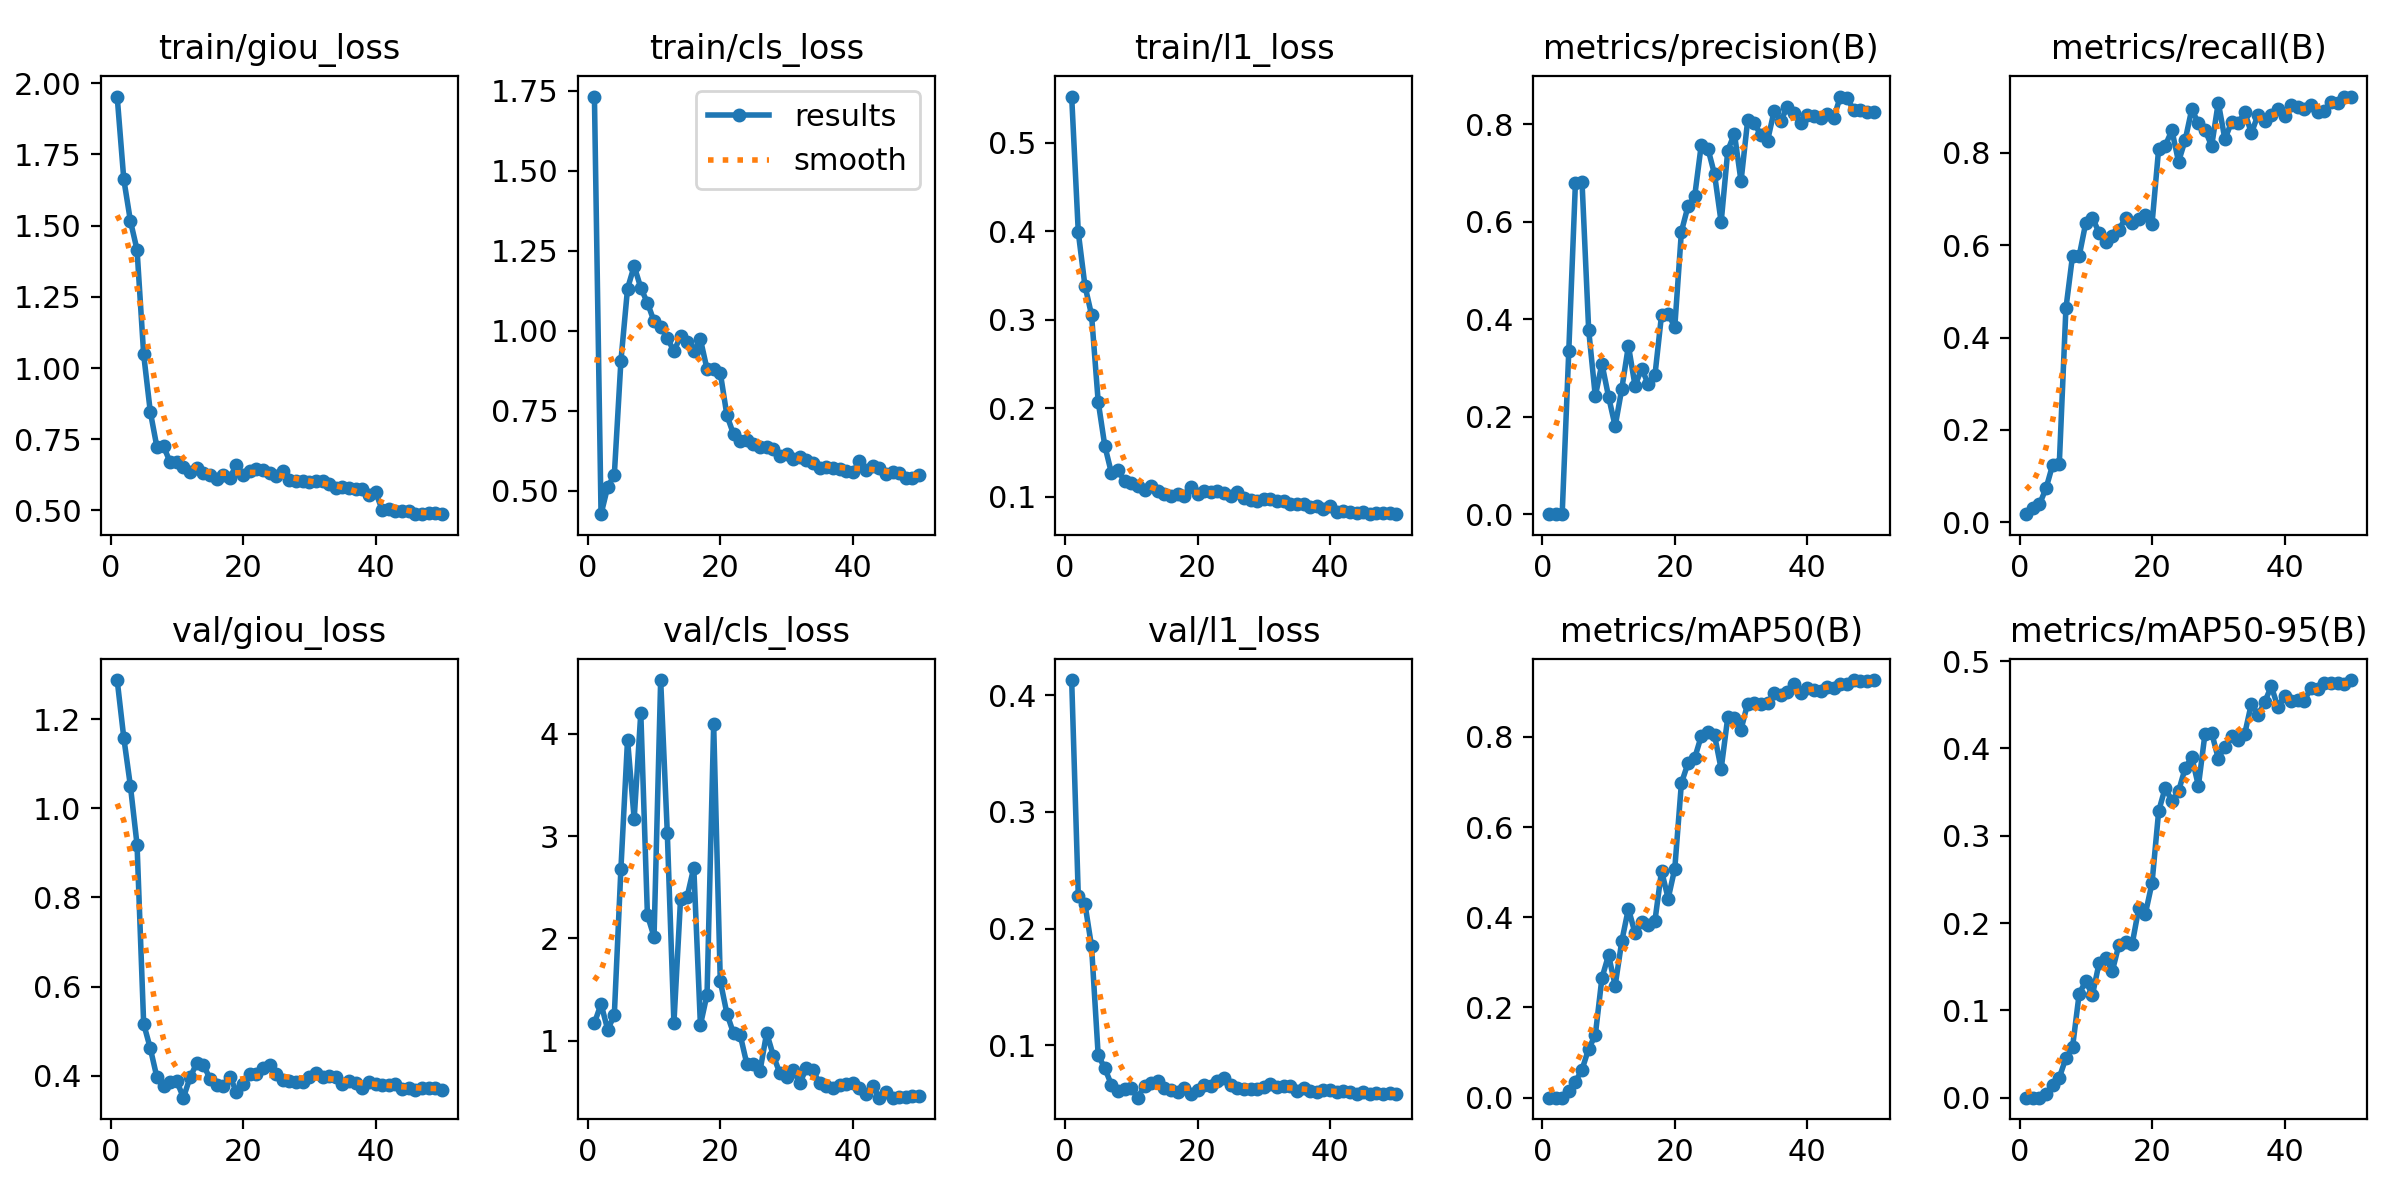


--- confusion_matrix.png ---


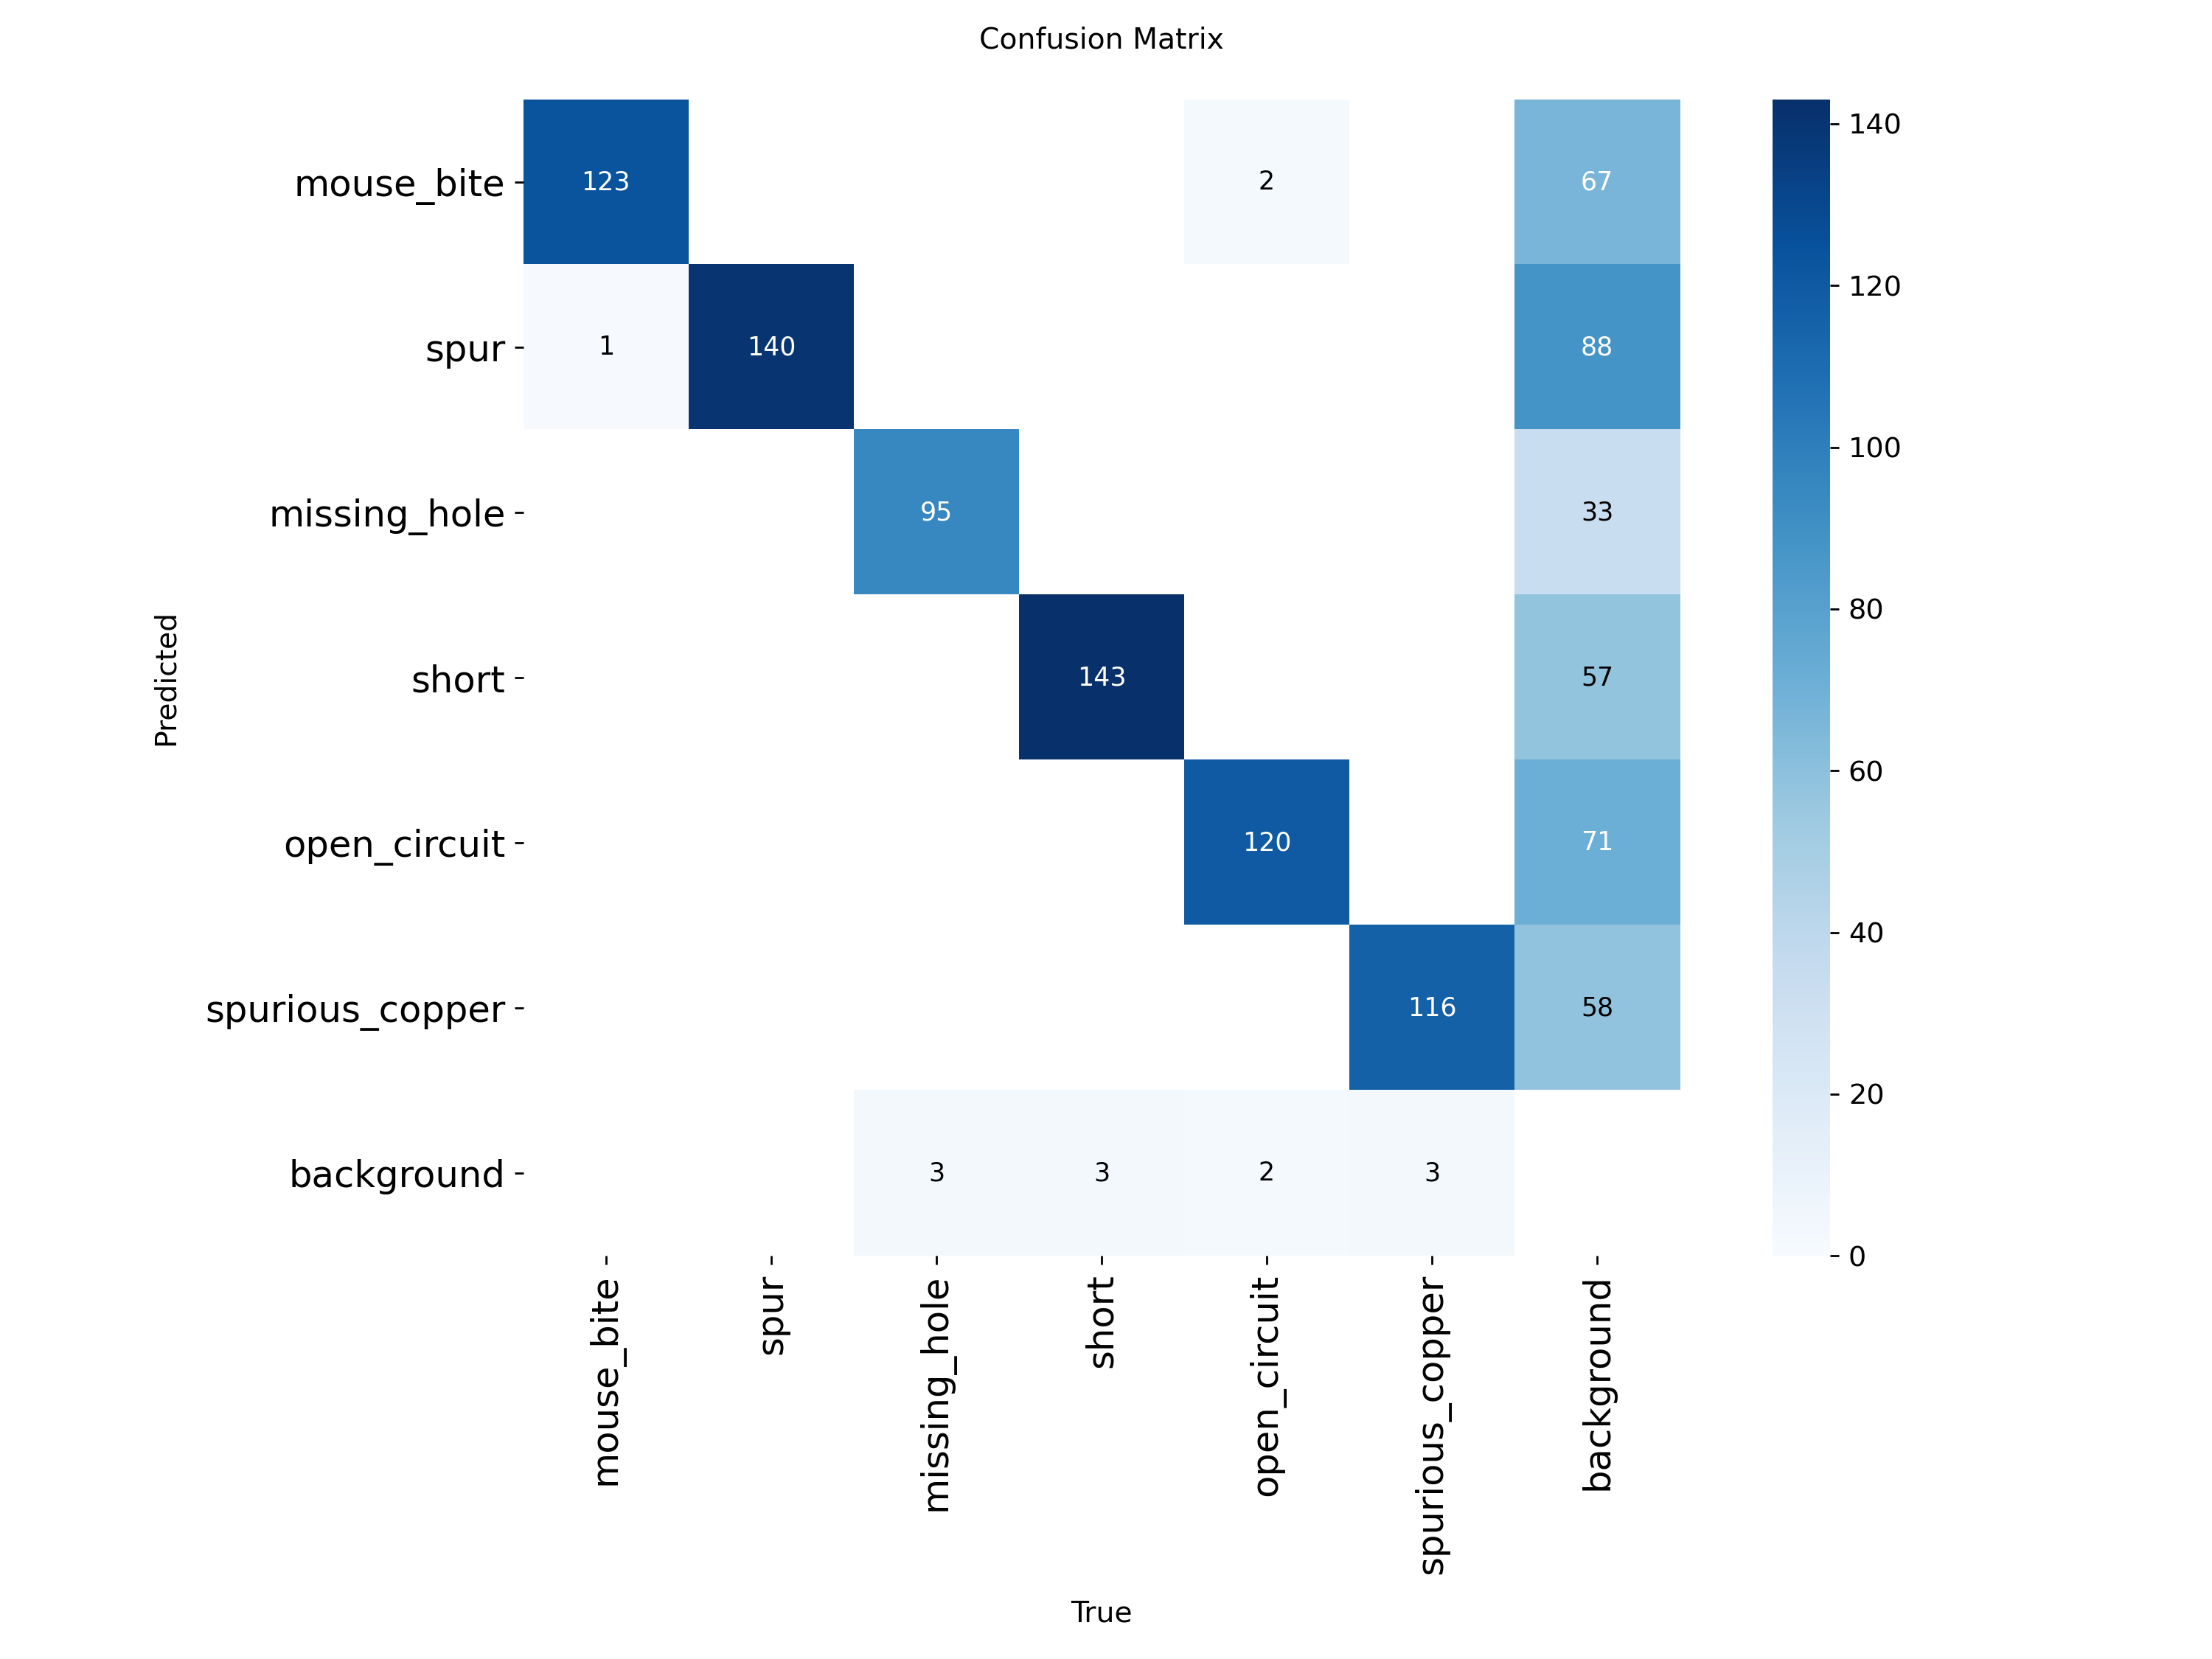


--- confusion_matrix_normalized.png ---


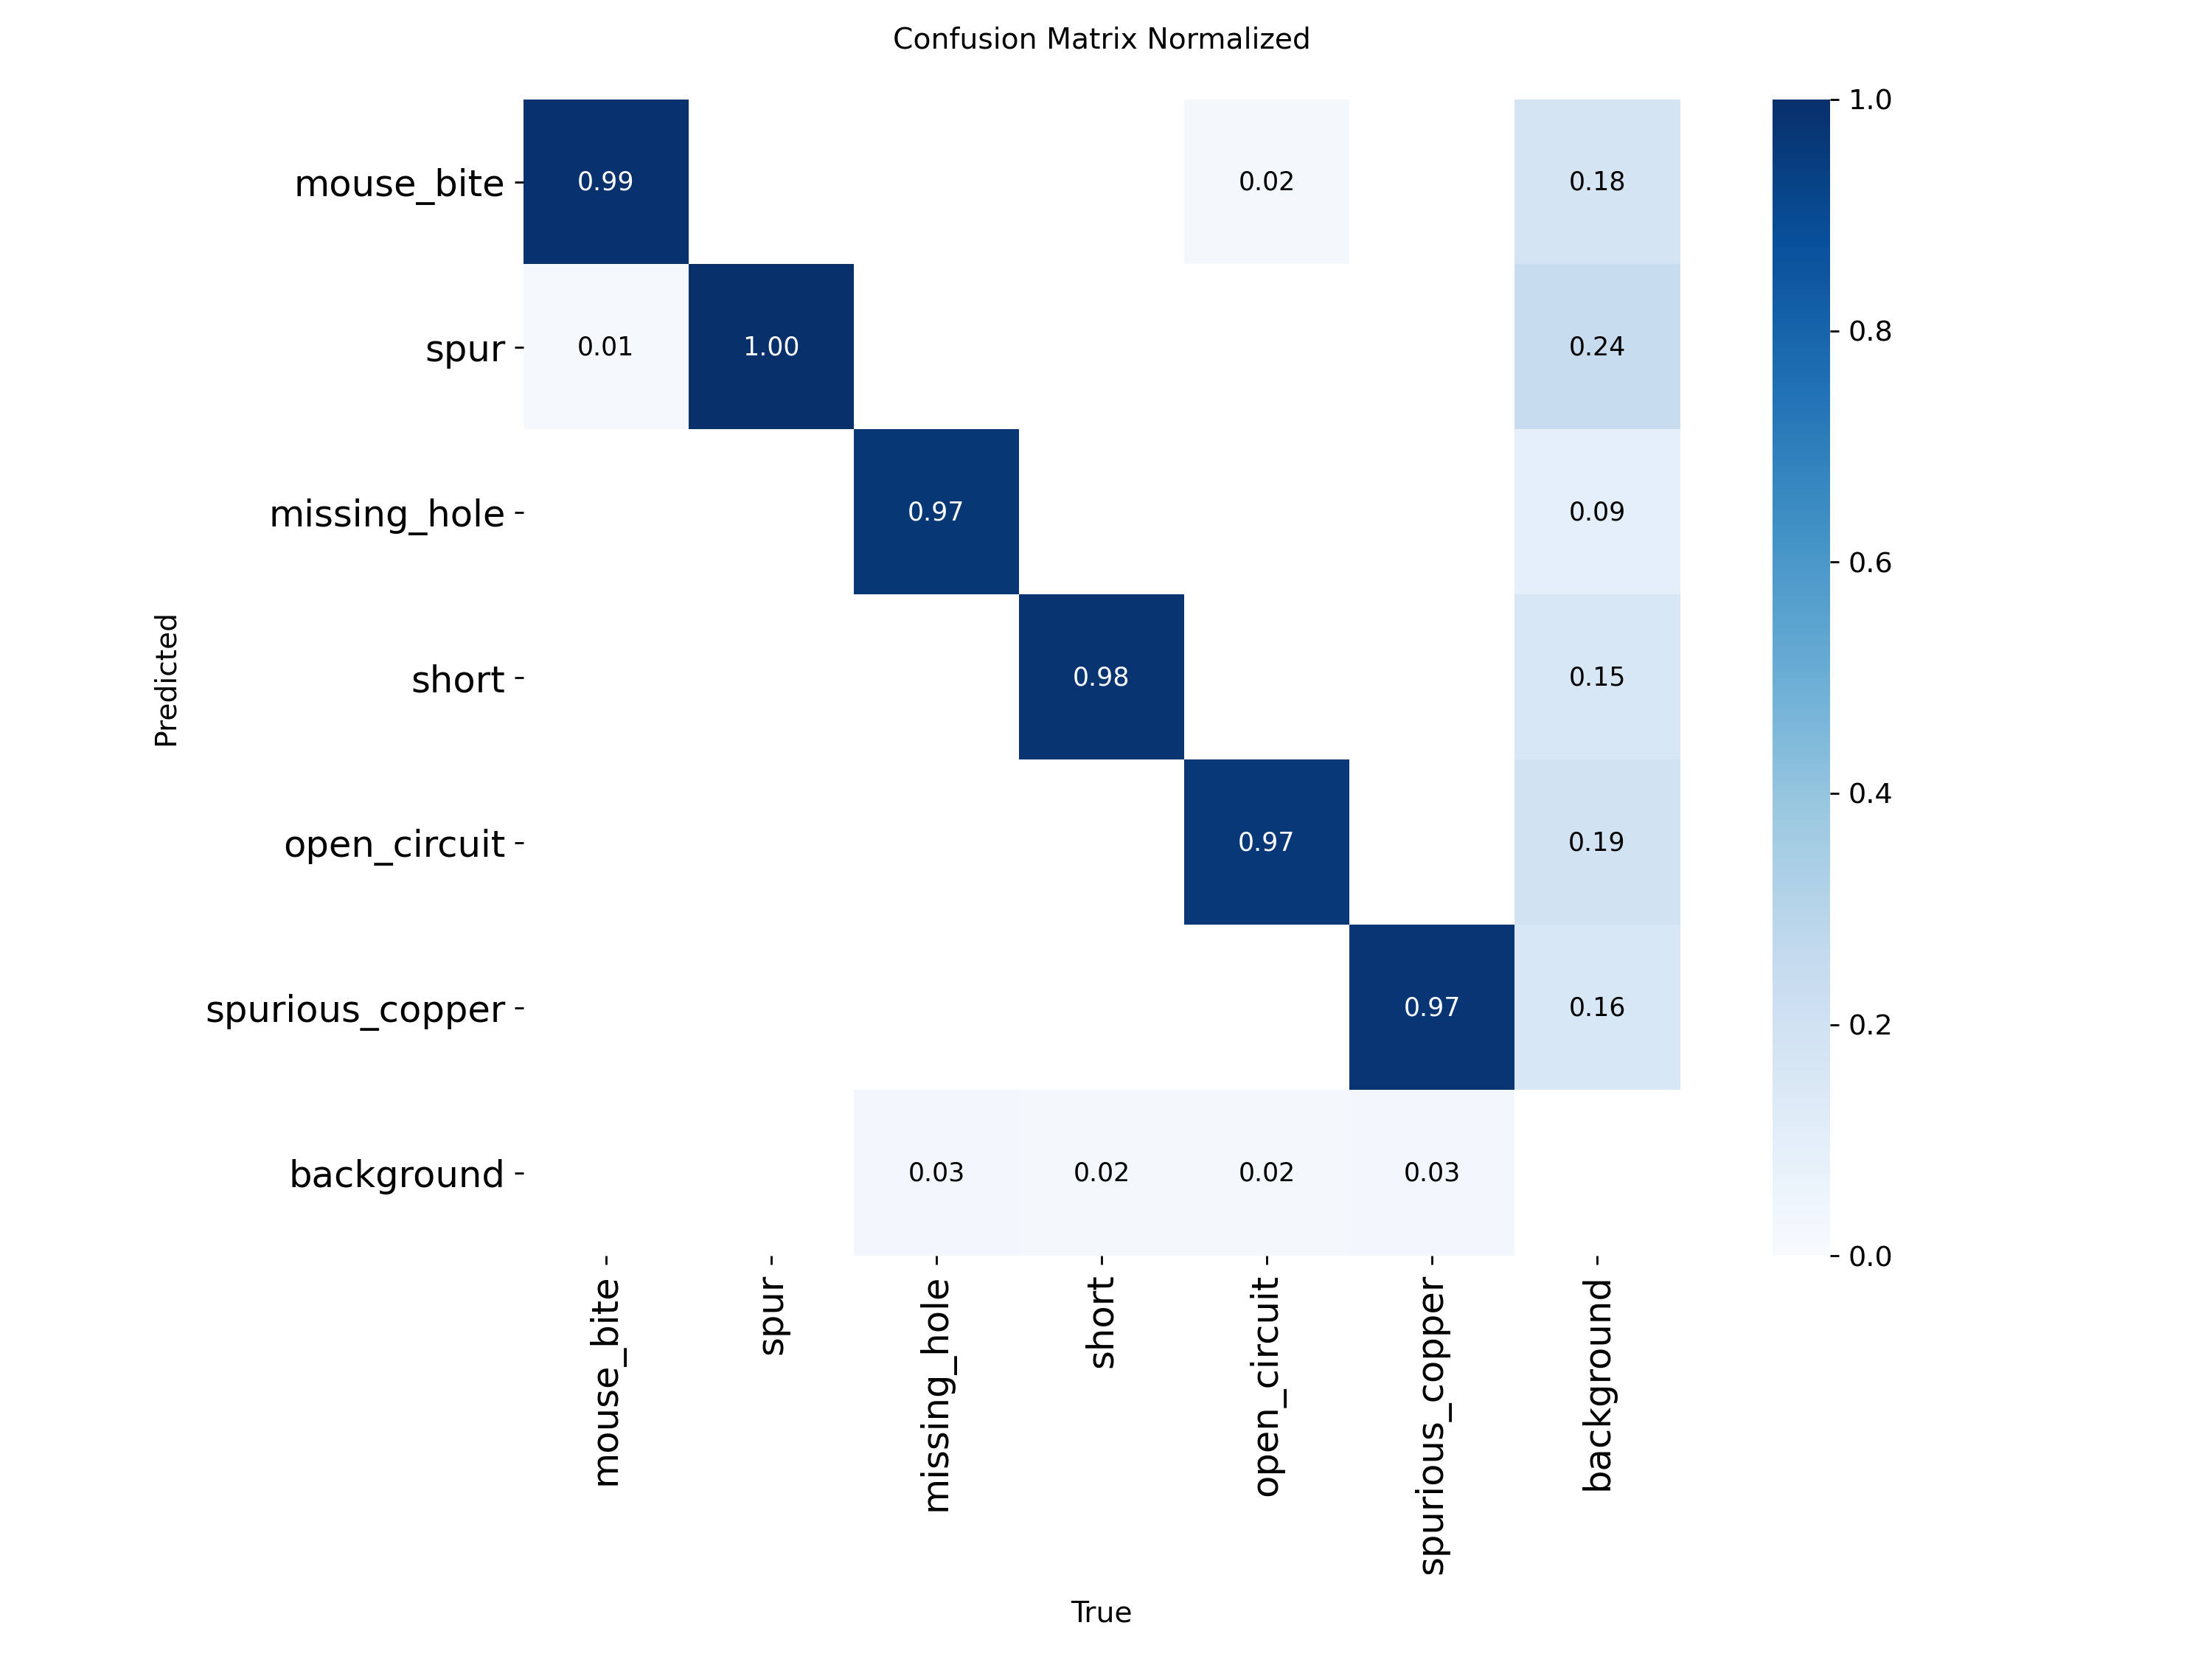

Gráfico não encontrado: F1_curve.png
Gráfico não encontrado: P_curve.png
Gráfico não encontrado: R_curve.png
Gráfico não encontrado: PR_curve.png


In [8]:
# Exibir gráficos de treinamento gerados pelo Ultralytics
from IPython.display import display, Image as IPImage

plots_to_show = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png",
]

for plot_name in plots_to_show:
    # Verifica tanto no diretório de treino quanto no de teste
    for search_dir in [results_dir, PROJECT_RUN_DIR / f"{run_name}_test"]:
        plot_path = search_dir / plot_name
        if plot_path.exists():
            print(f"\n--- {plot_name} ---")
            display(IPImage(filename=str(plot_path)))
            break
    else:
        print(f"Gráfico não encontrado: {plot_name}")

## 5. Inferência em Imagens de Teste

Nesta seção, realizamos inferência em imagens do conjunto de teste para visualizar as predições do RT-DETR. Isso permite verificar qualitativamente a qualidade das detecções.

In [9]:
# Inferência visual em imagens de teste
import random

if best_model_path.exists():
    test_images = list(test_images_dir.glob("*.jpg")) + list(test_images_dir.glob("*.png"))
    
    if len(test_images) == 0:
        print("Nenhuma imagem de teste encontrada.")
    else:
        random.seed(42)
        sample_images = random.sample(test_images, min(6, len(test_images)))

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for idx, img_path in enumerate(sample_images):
            results_inf = best_model.predict(
                source=str(img_path),
                imgsz=640,
                conf=0.25,
                device=device_id,
                verbose=False,
            )

            # Obter a imagem anotada
            annotated = results_inf[0].plot()
            # Converter BGR -> RGB
            annotated_rgb = annotated[:, :, ::-1]

            axes[idx].imshow(annotated_rgb)
            axes[idx].set_title(img_path.name, fontsize=10)
            axes[idx].axis("off")

        # Esconder eixos extras
        for idx in range(len(sample_images), len(axes)):
            axes[idx].axis("off")

        plt.suptitle("RT-DETR: Predições em Imagens de Teste", fontsize=16, fontweight="bold")
        plt.tight_layout()

        inference_plot_path = results_dir / "test_inference_samples.png"
        plt.savefig(inference_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Amostras salvas em: {inference_plot_path}")
else:
    print("Execute o treinamento primeiro para gerar o melhor modelo.")

<Figure size 1800x1200 with 6 Axes>

Amostras salvas em: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/rtdetr/20260505_0005_rtdetr-l_img640_e50_bs4_seed42_baseline/test_inference_samples.png


## 6. Conclusão

O modelo **RT-DETR** foi treinado e avaliado no dataset de defeitos em PCBs, seguindo a mesma metodologia utilizada nos notebooks de YOLOv11, Faster R-CNN e RetinaNet.

### Principais características do RT-DETR:
- **Arquitetura baseada em Transformers:** Utiliza mecanismos de atenção para capturar relações globais na imagem.
- **Detecção End-to-End:** Elimina a necessidade de NMS no pós-processamento, simplificando o pipeline.
- **Backbone HGNetv2:** Backbone eficiente que equilibra precisão e velocidade.
- **Transfer Learning:** Modelo pré-treinado em COCO, adaptado para as 6 classes de defeitos em PCBs.

### Próximos Passos:
1. Comparar os resultados com os demais modelos (YOLOv11, Faster R-CNN, RetinaNet).
2. Integrar os resultados no dashboard de monitoramento industrial.
3. Avaliar a velocidade de inferência para viabilidade em ambiente de produção.

# 7. Referências  

- Zhao, Y., Lv, W., Xu, S., et al. (2024). DETRs Beat YOLOs on Real-time Object Detection. CVPR 2024.
- Ultralytics RT-DETR Documentation: https://docs.ultralytics.com/models/rtdetr/
- PCB Defect Dataset: https://www.kaggle.com/datasets/norbertelter/pcb-defect-dataset
- Roboflow: https://roboflow.com/